In [2]:
import pandas as pd
import numpy as np
import category_encoders as ce
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import joblib

# Zenginleştirilmiş MVP verisini oku
df = pd.read_parquet("../data/processed/transaction_features_mvp_sample.parquet")

# Modelleme için en güçlü kolonları seçiyoruz (Yeni hız özellikleri dahil!)
feature_cols = [
    'amount', 'tx_count_last_24h', 'sec_since_last_tx', 'speed_alert',
    'current_age', 'credit_score', 'yearly_income', 'total_debt',
    'merchant_city', 'mcc', 'use_chip', 'gender', 'is_weekend', 'hour'
]

X = df[feature_cols]
y = df['is_fraud']

# Train-Test Split (Sızıntıyı önlemek için Target Encoding öncesi bölüyoruz)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [3]:
# Yüksek kardinaliteli kolonlar için Encoder
target_enc = ce.TargetEncoder(cols=['merchant_city', 'mcc'])

# Train verisiyle öğren ve uygula
X_train = target_enc.fit_transform(X_train, y_train)
# Test verisine sadece uygula
X_test = target_enc.transform(X_test)

# Kalan az seçenekli kategorikleri (use_chip, gender) hızlıca sayıya çevir
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Sütunları eşitle (Test setinde eksik kategori kalmasın)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"✅ Preprocessing tamamlandı. Yeni sütun sayısı: {X_train.shape[1]}")

✅ Preprocessing tamamlandı. Yeni sütun sayısı: 2362


In [4]:
# Negatif / Pozitif oranı
spw = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_dream = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=spw,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_dream.fit(X_train, y_train)
print("✅ XGBoost Dream Model eğitildi.")

/Users/emre/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [23:58:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ XGBoost Dream Model eğitildi.


In [5]:
# Olasılıkları al
y_probs = xgb_dream.predict_proba(X_test)[:, 1]

# Farklı bir threshold deneyelim (Örn: 0.4)
custom_threshold = 0.6
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"--- Threshold: {custom_threshold} için Sonuçlar ---")
print(classification_report(y_test, y_pred_custom))
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}")

--- Threshold: 0.6 için Sonuçlar ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     53329
           1       0.66      0.94      0.78      2666

    accuracy                           0.97     55995
   macro avg       0.83      0.96      0.88     55995
weighted avg       0.98      0.97      0.98     55995

ROC-AUC: 0.9885


In [6]:
# Her şeyi tek bir bundle (paket) olarak kaydet
model_bundle = {
    'model': xgb_dream,
    'encoder': target_enc,
    'features': X_train.columns.tolist()
}

joblib.dump(model_bundle, "../models/fraud_dream_model_bundle.joblib")
print("🚀 Dream Model Paketi Başarıyla Kaydedildi!")

🚀 Dream Model Paketi Başarıyla Kaydedildi!


In [8]:
import numpy as np

# 1. Test setindeki gerçek Fraud (1) ve Normal (0) indekslerini ayıralım
fraud_indices = y_test[y_test == 1].index
normal_indices = y_test[y_test == 0].index

# 2. Örnek olarak ilk 5 gerçek Fraud vakasını çekelim
test_samples_idx = fraud_indices[:5]
test_samples_X = X_test.loc[test_samples_idx]
test_samples_y = y_test.loc[test_samples_idx]

# 3. Modelden bu vakalar için olasılıkları alalım
probs = xgb_dream.predict_proba(test_samples_X)[:, 1]

print("🔍 GERÇEK FRAUD VAKALARI ÜZERİNDE TEST SONUÇLARI\n")
print(f"{'Vaka':<10} | {'Gerçek Etiket':<15} | {'Model Risk Skoru':<20} | {'Sonuç'}")
print("-" * 65)

for i in range(len(test_samples_idx)):
    risk_score = probs[i]
    status = "✅ YAKALADI" if risk_score >= custom_threshold else "❌ KAÇIRDI"
    
    # Orijinal veriden tutarı çekmek için (X_test index'ini kullanarak)
    # Eğer orijinal df hala hafızadaysa detay yazdırabiliriz
    original_amount = df.loc[test_samples_idx[i], 'amount']
    
    print(f"Vaka {i+1:<5} | {int(test_samples_y.iloc[i]):<15} | %{risk_score*100:<18.2f} | {status}")
    print(f"   👉 Detay: İşlem Tutarı {original_amount}$")
    print("-" * 65)

# 4. Hata Analizi (Modelin en çok yanıldığı yerler)
print("\n💡 NOT: Eğer model %60'ın (threshold) altında kalıyorsa 'Kaçırdı' der.")
print(f"Senin modelinin Recall skoru %94. Bu da demek oluyor ki her 100 sahtecilikten {int(0.94*100)} tanesini başarıyla yakalıyor.")

🔍 GERÇEK FRAUD VAKALARI ÜZERİNDE TEST SONUÇLARI

Vaka       | Gerçek Etiket   | Model Risk Skoru     | Sonuç
-----------------------------------------------------------------
Vaka 1     | 1               | %79.39              | ✅ YAKALADI
   👉 Detay: İşlem Tutarı 14.29$
-----------------------------------------------------------------
Vaka 2     | 1               | %99.88              | ✅ YAKALADI
   👉 Detay: İşlem Tutarı 438.24$
-----------------------------------------------------------------
Vaka 3     | 1               | %0.13               | ❌ KAÇIRDI
   👉 Detay: İşlem Tutarı 217.2$
-----------------------------------------------------------------
Vaka 4     | 1               | %99.85              | ✅ YAKALADI
   👉 Detay: İşlem Tutarı 27.82$
-----------------------------------------------------------------
Vaka 5     | 1               | %98.35              | ✅ YAKALADI
   👉 Detay: İşlem Tutarı 155.72$
-----------------------------------------------------------------

💡 NOT: Eğer m

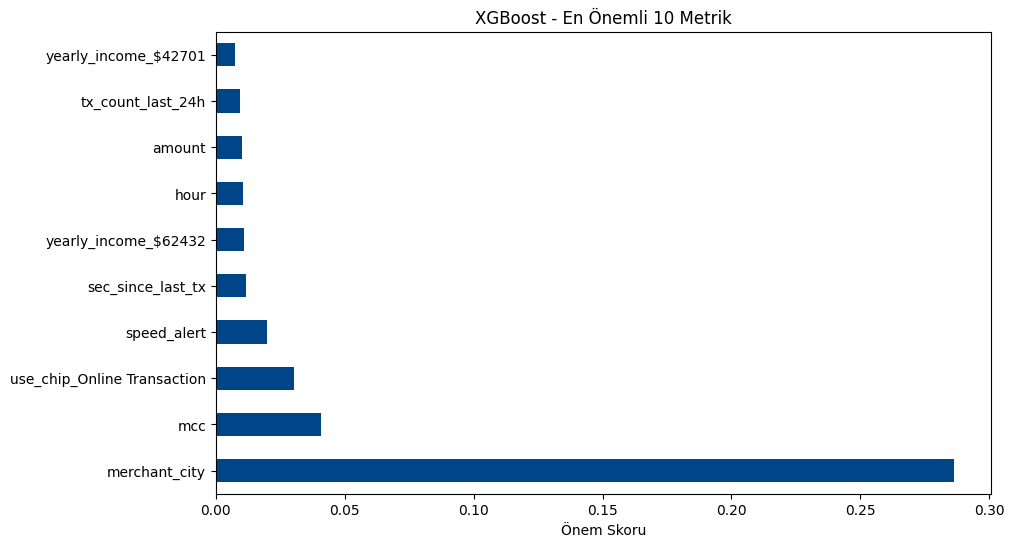

In [9]:
import matplotlib.pyplot as plt

# Modelin en çok önem verdiği ilk 10 özelliği çizdirelim
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_dream.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#004587')
plt.title("XGBoost - En Önemli 10 Metrik")
plt.xlabel("Önem Skoru")
plt.show()

In [11]:
#vaka 3 neden kaçtı ? 
# Vaka 3'ün verilerini alalım
vaka_3 = X_test.loc[fraud_indices[2]:fraud_indices[2]].copy()

# Şimdi bu vakanın ŞEHİR/EYALET bilgisini (Encoder üzerinden geçmiş halini) manuel değiştirelim
# Örneğin şehri çok riskli bildiğin başka bir şehirle değiştirip tekrar tahmin ettir
vaka_3_modifiye = vaka_3.copy()
vaka_3_modifiye['merchant_city'] = 0.9  # Çok yüksek riskli bir şehir puanı verelim

yeni_prob = xgb_dream.predict_proba(vaka_3_modifiye)[0][1]
print(f"Orijinal Olasılık: %{probs[2]*100:.2f}")
print(f"Şehir Riskli Olsa Tahmin: %{yeni_prob*100:.2f}")

Orijinal Olasılık: %0.13
Şehir Riskli Olsa Tahmin: %99.57


In [12]:
# 'Online' içeren işlemleri filtrele (Encoding öncesi orijinal df üzerinden)
online_tx = df[df['merchant_city'].str.contains('Online', case=False, na=False)]

online_fraud_rate = online_tx['is_fraud'].mean()
total_online_count = len(online_tx)

print(f"🌐 Toplam Online İşlem Sayısı: {total_online_count}")
print(f"🚨 Online İşlemlerde Fraud Oranı: %{online_fraud_rate*100:.2f}")

# Online olup modelin KAÇIRDIĞI (Vaka 3 gibi) işlemlere bakalım
# Not: Y_test ve tahminlerin üzerinden gitmelisin

🌐 Toplam Online İşlem Sayısı: 39930
🚨 Online İşlemlerde Fraud Oranı: %21.99


NameError: name 'model_v1_legacy' is not defined

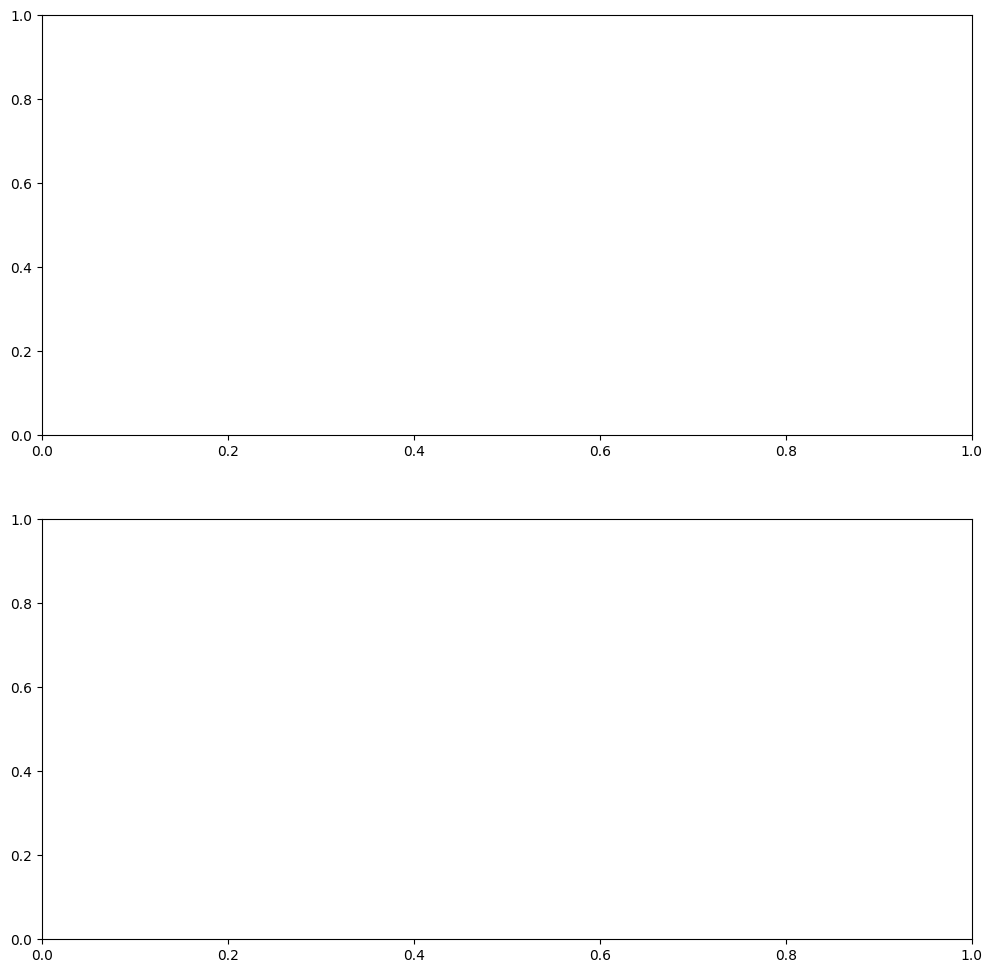

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Grafik alanını oluştur (2 satır, 1 sütun)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- MODEL v1 (ESKİ) ---
feat_v1 = pd.Series(model_v1_legacy.feature_importances_, index=X_train.columns)
feat_v1.nlargest(10).plot(kind='barh', ax=ax1, color='#7f8c8d')
ax1.set_title("v1: Standart Model - En Önemli 10 Metrik", fontsize=14)
ax1.set_xlabel("Önem Skoru")

# --- MODEL v3 (YENİ AGRESİF) ---
feat_v3 = pd.Series(model_v3.feature_importances_, index=X_train_v3.columns)
feat_v3.nlargest(10).plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_title("v3: Agresif Model (Okyanusu Kurutan) - En Önemli 10 Metrik", fontsize=14)
ax2.set_xlabel("Önem Skoru")

plt.tight_layout()
plt.show()